In [32]:
import pandas as pd
import numpy as np

# Path to the dataset
file_path = "default of credit card clients.xls"

# Load the raw Excel file
# The UCI dataset contains extra header rows

raw = pd.read_excel(file_path, header=None)

# Extract the correct column names (second row in file)
columns = raw.iloc[1].tolist()

# Extract actual data (starts on row 3)
df = raw.iloc[2:].copy()
df.columns = columns

# Reset index
df = df.reset_index(drop=True)

# Convert columns to numeric

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Rename target variable

df = df.rename(columns={"default payment next month": "default_next_month"})

# Drop ID column (not useful for prediction)

if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Display dataset summary

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape:
(30000, 24)

Column names:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_next_month']

First 5 rows:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Missing values per column:
LIMIT_BAL             0
SEX                   0
EDUCATION             0
MARRIAGE              0
AGE                   0
PAY_0                 0
PAY_2                 0
PAY_3                 0
PAY_4                 0
PAY_5                 0
PAY_6                 0
BILL_AMT1             0
BILL_AMT2             0
BILL_AMT3             0
BILL_AMT4             0
BILL_AMT5             0
BILL_AMT6             0
PAY_AMT1              0
PAY_AMT2              0
PAY_AMT3              0
PAY_AMT4              0
PAY_AMT5              0
PAY_AMT6              0
default_next_month    0
dtype: int64


In [33]:
# Inspect unique values before cleaning

print("Unique values BEFORE cleaning:\n")

print("SEX:")
print(sorted(df["SEX"].dropna().unique()))

print("\nEDUCATION:")
print(sorted(df["EDUCATION"].dropna().unique()))

print("\nMARRIAGE:")
print(sorted(df["MARRIAGE"].dropna().unique()))

pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in pay_cols:
    print(f"\n{col}:")
    print(sorted(df[col].dropna().unique()))

# Clean known category quirks

# EDUCATION:
# 1 = graduate school, 2 = university, 3 = high school
# Values 0, 5, 6 are usually treated as "other/unknown"
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE:
# 1 = married, 2 = single, 3 = other
# Value 0 is usually treated as "other"
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

# SEX is typically already valid in this dataset, so we leave it unchanged

# Inspect unique values after cleaning

print("\n" + "=" * 60)
print("Unique values AFTER cleaning:\n")

print("SEX:")
print(sorted(df["SEX"].dropna().unique()))

print("\nEDUCATION:")
print(sorted(df["EDUCATION"].dropna().unique()))

print("\nMARRIAGE:")
print(sorted(df["MARRIAGE"].dropna().unique()))

for col in pay_cols:
    print(f"\n{col}:")
    print(sorted(df[col].dropna().unique()))

# Quick frequency tables for cleaned categorical variables

print("\n" + "=" * 60)
print("Value counts for cleaned categorical variables:\n")

print("SEX value counts:")
print(df["SEX"].value_counts(dropna=False).sort_index())

print("\nEDUCATION value counts:")
print(df["EDUCATION"].value_counts(dropna=False).sort_index())

print("\nMARRIAGE value counts:")
print(df["MARRIAGE"].value_counts(dropna=False).sort_index())

Unique values BEFORE cleaning:

SEX:
[1, 2]

EDUCATION:
[0, 1, 2, 3, 4, 5, 6]

MARRIAGE:
[0, 1, 2, 3]

PAY_0:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_2:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_3:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_4:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_5:
[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]

PAY_6:
[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]

Unique values AFTER cleaning:

SEX:
[1, 2]

EDUCATION:
[1, 2, 3, 4]

MARRIAGE:
[1, 2, 3]

PAY_0:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_2:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_3:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_4:
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_5:
[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]

PAY_6:
[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]

Value counts for cleaned categorical variables:

SEX value counts:
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION value counts:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE value counts:
MARRIAGE
1    13659
2    15964
3      377
N

In [34]:
# Target variable

y = df["default_next_month"].astype(int)

print("Target distribution:")
print(y.value_counts(normalize=True))

# Demographic / static features

demographic_cols = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE"
]

# 6-month history columns

pay_cols_full = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

bill_cols_full = [
    "BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6"
]

pay_amt_cols_full = [
    "PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"
]

# 3-month history

pay_cols_3m = ["PAY_0","PAY_2","PAY_3"]

bill_cols_3m = ["BILL_AMT1","BILL_AMT2","BILL_AMT3"]

pay_amt_cols_3m = ["PAY_AMT1","PAY_AMT2","PAY_AMT3"]

# 1-month history

pay_cols_1m = ["PAY_0"]

bill_cols_1m = ["BILL_AMT1"]

pay_amt_cols_1m = ["PAY_AMT1"]

# Raw feature matrices

X_1m_raw = df[demographic_cols + pay_cols_1m + bill_cols_1m + pay_amt_cols_1m].copy()

X_3m_raw = df[demographic_cols + pay_cols_3m + bill_cols_3m + pay_amt_cols_3m].copy()

X_6m_raw = df[demographic_cols + pay_cols_full + bill_cols_full + pay_amt_cols_full].copy()

print("\nFeature matrix shapes:")

print("1-month features:", X_1m_raw.shape)
print("3-month features:", X_3m_raw.shape)
print("6-month features:", X_6m_raw.shape)

print("\nTarget shape:", y.shape)

Target distribution:
default_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Feature matrix shapes:
1-month features: (30000, 8)
3-month features: (30000, 14)
6-month features: (30000, 23)

Target shape: (30000,)


In [35]:
def build_summary_features(df_in, pay_cols, bill_cols, pay_amt_cols):
    X = df_in.copy()
    # Repayment behavior
    X["pay_max"] = X[pay_cols].max(axis=1)
    X["pay_mean"] = X[pay_cols].mean(axis=1)
    X["num_delinq_ge1"] = (X[pay_cols] >= 1).sum(axis=1)
    X["num_delinq_ge2"] = (X[pay_cols] >= 2).sum(axis=1)
    X["num_clean_months"] = (X[pay_cols] <= 0).sum(axis=1)

    # Delinquency trend / worsening
    # For this dataset, the first column in each chosen window is the
    # most recent month and the last is the oldest month.
    worsening_count = np.zeros(len(X), dtype=int)
    for i in range(len(pay_cols) - 1):
        worsening_count += (X[pay_cols[i]] > X[pay_cols[i + 1]]).astype(int)

    X["delinq_worsening_count"] = worsening_count
    X["delinq_recent_minus_old"] = X[pay_cols[0]] - X[pay_cols[-1]]

    # Bill behavior
    X["bill_max"] = X[bill_cols].max(axis=1)
    X["bill_mean"] = X[bill_cols].mean(axis=1)
    X["bill_std"] = X[bill_cols].std(axis=1).fillna(0)
    X["bill_recent_minus_old"] = X[bill_cols[0]] - X[bill_cols[-1]]

    # Utilization proxy: bill / credit limit
    # Protect against divide-by-zero
    limit_safe = X["LIMIT_BAL"].replace(0, np.nan)

    util_df = X[bill_cols].div(limit_safe, axis=0)
    X["util_mean_proxy"] = util_df.mean(axis=1)
    X["util_max_proxy"] = util_df.max(axis=1)
    X["util_recent_proxy"] = X[bill_cols[0]] / limit_safe

    # Replace any inf / nan created by division
    util_cols = ["util_mean_proxy", "util_max_proxy", "util_recent_proxy"]
    X[util_cols] = X[util_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    # Payment behavior
    X["pay_amt_total"] = X[pay_amt_cols].sum(axis=1)
    X["pay_amt_mean"] = X[pay_amt_cols].mean(axis=1)
    X["pay_amt_std"] = X[pay_amt_cols].std(axis=1).fillna(0)

    # Payment-rate features: payment / bill
    # Use absolute bill and floor denominator at 1 for safety
    rate_cols = []
    for bcol, pcol in zip(bill_cols, pay_amt_cols):
        rate_name = f"{pcol}_over_{bcol}"
        denom = np.maximum(X[bcol].abs(), 1)
        X[rate_name] = X[pcol] / denom
        X[rate_name] = X[rate_name].replace([np.inf, -np.inf], np.nan).fillna(0)
        rate_cols.append(rate_name)

    X["payment_rate_mean"] = X[rate_cols].mean(axis=1)
    X["payment_rate_min"] = X[rate_cols].min(axis=1)
    X["payment_rate_recent"] = X[rate_cols[0]]

    # Recent bill-payment gap
    X["recent_bill_minus_payment"] = X[bill_cols[0]] - X[pay_amt_cols[0]]

    return X

# Build summary-feature datasets for each time window

X_1m_sum = build_summary_features(
    X_1m_raw,
    pay_cols_1m,
    bill_cols_1m,
    pay_amt_cols_1m
)

X_3m_sum = build_summary_features(
    X_3m_raw,
    pay_cols_3m,
    bill_cols_3m,
    pay_amt_cols_3m
)

X_6m_sum = build_summary_features(
    X_6m_raw,
    pay_cols_full,
    bill_cols_full,
    pay_amt_cols_full
)

# Display summary info
print("Summary feature matrix shapes:")
print("X_1m_sum:", X_1m_sum.shape)
print("X_3m_sum:", X_3m_sum.shape)
print("X_6m_sum:", X_6m_sum.shape)

print("\nExample engineered columns:")
engineered_cols = [
    "pay_max",
    "pay_mean",
    "num_delinq_ge1",
    "num_delinq_ge2",
    "delinq_worsening_count",
    "delinq_recent_minus_old",
    "bill_max",
    "bill_mean",
    "util_mean_proxy",
    "util_max_proxy",
    "pay_amt_total",
    "payment_rate_mean",
    "payment_rate_min",
    "payment_rate_recent",
    "recent_bill_minus_payment"
]

print([col for col in engineered_cols if col in X_6m_sum.columns])

print("\nPreview of engineered 6-month feature set:")
display(X_6m_sum.head())

Summary feature matrix shapes:
X_1m_sum: (30000, 30)
X_3m_sum: (30000, 38)
X_6m_sum: (30000, 50)

Example engineered columns:
['pay_max', 'pay_mean', 'num_delinq_ge1', 'num_delinq_ge2', 'delinq_worsening_count', 'delinq_recent_minus_old', 'bill_max', 'bill_mean', 'util_mean_proxy', 'util_max_proxy', 'pay_amt_total', 'payment_rate_mean', 'payment_rate_min', 'payment_rate_recent', 'recent_bill_minus_payment']

Preview of engineered 6-month feature set:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT1_over_BILL_AMT1,PAY_AMT2_over_BILL_AMT2,PAY_AMT3_over_BILL_AMT3,PAY_AMT4_over_BILL_AMT4,PAY_AMT5_over_BILL_AMT5,PAY_AMT6_over_BILL_AMT6,payment_rate_mean,payment_rate_min,payment_rate_recent,recent_bill_minus_payment
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0.000000,0.222115,0.000000,0.000000,0.000000,0.000000,0.037019,0.000000,0.000000,3913
1,120000,2,2,2,26,-1,2,0,0,0,...,0.000000,0.579710,0.372856,0.305623,0.000000,0.613309,0.311916,0.000000,0.000000,2682
2,90000,2,2,2,34,0,0,0,0,0,...,0.051917,0.106937,0.073752,0.069779,0.066899,0.321564,0.115141,0.051917,0.051917,27721
3,50000,2,2,1,37,0,0,0,0,0,...,0.042562,0.041859,0.024345,0.038850,0.036914,0.033844,0.036396,0.024345,0.042562,44990
4,50000,1,2,1,57,-1,0,-1,0,0,...,0.232099,6.469312,0.279057,0.429799,0.035987,0.035492,1.246958,0.035492,0.232099,6617


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Train/test split
# use the 6-month summary-feature dataset for the first model

X_train, X_test, y_train, y_test = train_test_split(
    X_6m_sum,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTrain default rate:")
print(y_train.mean())

print("\nTest default rate:")
print(y_test.mean())

# Identify categorical and numeric columns

categorical_cols = [col for col in ["SEX", "EDUCATION", "MARRIAGE"] if col in X_train.columns]
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numeric columns:")
print(len(numeric_cols))

# Preprocessing pipelines

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Logistic regression pipeline

logit_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

# Fit the model

logit_model.fit(X_train, y_train)

print("\nLogistic regression pipeline fitted successfully.")

# Generate predictions for the test set

y_test_proba = logit_model.predict_proba(X_test)[:, 1]
y_test_pred = logit_model.predict(X_test)

print("\nFirst 10 predicted probabilities:")
print(y_test_proba[:10])

print("\nFirst 10 predicted class labels:")
print(y_test_pred[:10])

X_train shape: (24000, 50)
X_test shape: (6000, 50)
y_train shape: (24000,)
y_test shape: (6000,)

Train default rate:
0.22120833333333334

Test default rate:
0.22116666666666668

Categorical columns:
['SEX', 'EDUCATION', 'MARRIAGE']

Number of numeric columns:
47

Logistic regression pipeline fitted successfully.

First 10 predicted probabilities:
[0.33253423 0.46651301 0.38541172 0.24543653 0.18659737 0.58722677
 0.25378798 0.14867936 0.18334303 0.27238131]

First 10 predicted class labels:
[0 0 0 0 0 1 0 0 0 0]


Logistic Regression Test Metrics:

ROC_AUC: 0.7559
PR_AUC: 0.5180
Accuracy: 0.7422
Precision: 0.4398
Recall: 0.6051
F1: 0.5094
Confusion_Matrix:
[[3650 1023]
 [ 524  803]]

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.78      0.83      4673
           1       0.44      0.61      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.74      0.76      6000



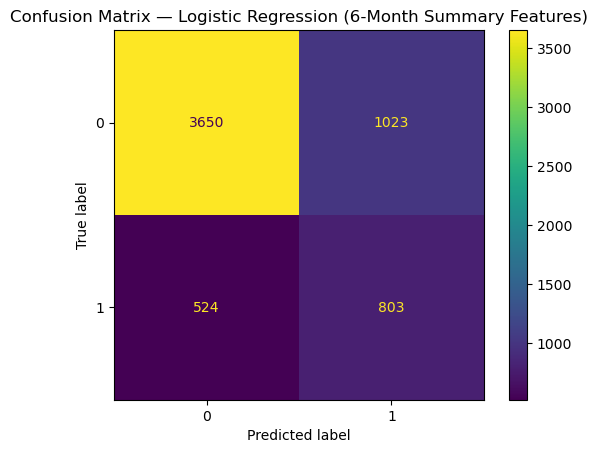

In [37]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Evaluation function
def evaluate_binary_model(y_true, y_proba, threshold=0.50):
    y_pred = (y_proba >= threshold).astype(int)

    metrics_dict = {
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Confusion_Matrix": confusion_matrix(y_true, y_pred)
    }

    return metrics_dict, y_pred

# Evaluate current model on the held-out test set
metrics_dict, y_pred_eval = evaluate_binary_model(y_test, y_test_proba, threshold=0.50)

print("Logistic Regression Test Metrics:\n")
for metric, value in metrics_dict.items():
    if metric != "Confusion_Matrix":
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}:\n{value}")

# Classification report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_eval, zero_division=0))

# Confusion matrix plot

disp = ConfusionMatrixDisplay(confusion_matrix=metrics_dict["Confusion_Matrix"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (6-Month Summary Features)")
plt.show()

In [38]:
import warnings
import pandas as pd
import numpy as np

from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Suppress warning messages
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Hyperparameter tuning function
def tune_logistic_regression(X, y):
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # Identify categorical and numeric columns
    categorical_cols = [col for col in ["SEX", "EDUCATION", "MARRIAGE"] if col in X.columns]
    numeric_cols = [col for col in X.columns if col not in categorical_cols]

    # Preprocessing
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    # Base pipeline
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ])

    # Hyperparameter grid
    param_grid = {
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 5, 10, 20]
    }

    # Cross-validation setup
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Grid search
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    # Fit
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    # Held-out test evaluation
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= 0.50).astype(int)

    results = {
        "best_params": grid.best_params_,
        "ROC_AUC": roc_auc_score(y_test, y_test_proba),
        "PR_AUC": average_precision_score(y_test, y_test_proba),
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "F1": f1_score(y_test, y_test_pred, zero_division=0),
        "Confusion_Matrix": confusion_matrix(y_test, y_test_pred)
    }

    return best_model, results


# Tune on 6-month summary features first
best_logit_6m, results_6m = tune_logistic_regression(X_6m_sum, y)

print("Best 6-Month Logistic Regression Results:\n")
print("Best Parameters:", results_6m["best_params"])
print(f"ROC_AUC:   {results_6m['ROC_AUC']:.4f}")
print(f"PR_AUC:    {results_6m['PR_AUC']:.4f}")
print(f"Accuracy:  {results_6m['Accuracy']:.4f}")
print(f"Precision: {results_6m['Precision']:.4f}")
print(f"Recall:    {results_6m['Recall']:.4f}")
print(f"F1:        {results_6m['F1']:.4f}")
print("Confusion Matrix:\n", results_6m["Confusion_Matrix"])

Fitting 5 folds for each of 12 candidates, totalling 60 fits


KeyboardInterrupt: 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Comparison of Tuned Logistic Regression Models Across Time Windows:



,window,best_penalty,best_C,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1
0,3 months,l1,1.0,0.7571,0.5156,0.7672,0.4777,0.5659,0.5181
1,6 months,l1,0.1,0.7558,0.5174,0.7432,0.4413,0.6066,0.5109
2,1 month,l1,1.0,0.7337,0.4917,0.7730,0.4872,0.5034,0.4952


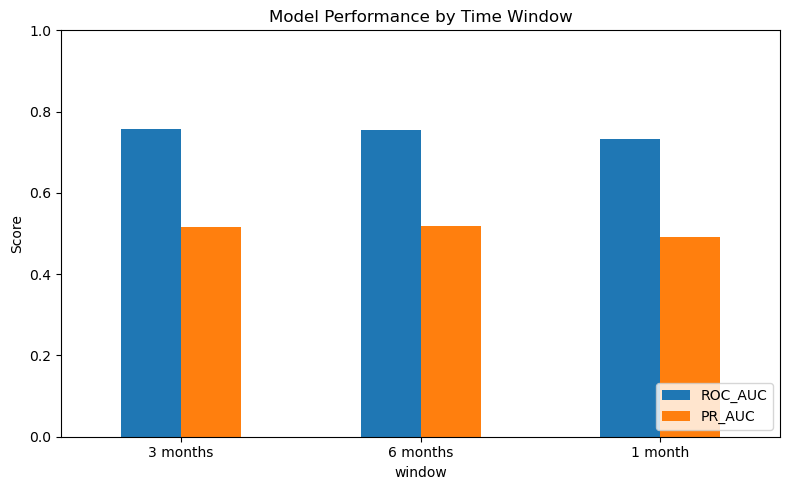

In [ ]:
# Train tuned logistic regression on each time window
best_logit_1m, results_1m = tune_logistic_regression(X_1m_sum, y)
best_logit_3m, results_3m = tune_logistic_regression(X_3m_sum, y)
best_logit_6m, results_6m = tune_logistic_regression(X_6m_sum, y)

# Build comparison table
comparison_rows = [
    {
        "window": "1 month",
        "best_penalty": results_1m["best_params"]["model__penalty"],
        "best_C": results_1m["best_params"]["model__C"],
        "ROC_AUC": results_1m["ROC_AUC"],
        "PR_AUC": results_1m["PR_AUC"],
        "Accuracy": results_1m["Accuracy"],
        "Precision": results_1m["Precision"],
        "Recall": results_1m["Recall"],
        "F1": results_1m["F1"]
    },
    {
        "window": "3 months",
        "best_penalty": results_3m["best_params"]["model__penalty"],
        "best_C": results_3m["best_params"]["model__C"],
        "ROC_AUC": results_3m["ROC_AUC"],
        "PR_AUC": results_3m["PR_AUC"],
        "Accuracy": results_3m["Accuracy"],
        "Precision": results_3m["Precision"],
        "Recall": results_3m["Recall"],
        "F1": results_3m["F1"]
    },
    {
        "window": "6 months",
        "best_penalty": results_6m["best_params"]["model__penalty"],
        "best_C": results_6m["best_params"]["model__C"],
        "ROC_AUC": results_6m["ROC_AUC"],
        "PR_AUC": results_6m["PR_AUC"],
        "Accuracy": results_6m["Accuracy"],
        "Precision": results_6m["Precision"],
        "Recall": results_6m["Recall"],
        "F1": results_6m["F1"]
    }
]

results_df = pd.DataFrame(comparison_rows)
results_df = results_df.sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)

# Display results
print("Comparison of Tuned Logistic Regression Models Across Time Windows:\n")
display(results_df.round(4))

# Plot ROC-AUC and PR-AUC by time window
plot_df = results_df.set_index("window")[["ROC_AUC", "PR_AUC"]]

ax = plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Model Performance by Time Window")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [17]:
# Evaluate simple traditional risk rules against the target
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rule_results = []

# Rule 1: Any recent delinquency
pred_recent_any_delinquency = (df["PAY_0"] >= 1).astype(int)

rule_results.append({
    "rule": "recent_any_delinquency (PAY_0 >= 1)",
    "Accuracy": accuracy_score(y, pred_recent_any_delinquency),
    "Precision": precision_score(y, pred_recent_any_delinquency, zero_division=0),
    "Recall": recall_score(y, pred_recent_any_delinquency, zero_division=0),
    "F1": f1_score(y, pred_recent_any_delinquency, zero_division=0)
})

# Rule 2: Severe recent delinquency
pred_recent_severe_delinquency = (df["PAY_0"] >= 2).astype(int)

rule_results.append({
    "rule": "recent_severe_delinquency (PAY_0 >= 2)",
    "Accuracy": accuracy_score(y, pred_recent_severe_delinquency),
    "Precision": precision_score(y, pred_recent_severe_delinquency, zero_division=0),
    "Recall": recall_score(y, pred_recent_severe_delinquency, zero_division=0),
    "F1": f1_score(y, pred_recent_severe_delinquency, zero_division=0)
})

# Rule 3: High utilization proxy
util_recent = df["BILL_AMT1"] / np.maximum(df["LIMIT_BAL"], 1)
pred_high_util = (util_recent >= 0.80).astype(int)

rule_results.append({
    "rule": "high_utilization_proxy (BILL_AMT1 / LIMIT_BAL >= 0.8)",
    "Accuracy": accuracy_score(y, pred_high_util),
    "Precision": precision_score(y, pred_high_util, zero_division=0),
    "Recall": recall_score(y, pred_high_util, zero_division=0),
    "F1": f1_score(y, pred_high_util, zero_division=0)
})

# Rule 4: Low recent payment rate
payment_rate_recent = df["PAY_AMT1"] / np.maximum(df["BILL_AMT1"].abs(), 1)
pred_low_payment_rate = (payment_rate_recent < 0.10).astype(int)

rule_results.append({
    "rule": "low_recent_payment_rate (PAY_AMT1 / |BILL_AMT1| < 0.1)",
    "Accuracy": accuracy_score(y, pred_low_payment_rate),
    "Precision": precision_score(y, pred_low_payment_rate, zero_division=0),
    "Recall": recall_score(y, pred_low_payment_rate, zero_division=0),
    "F1": f1_score(y, pred_low_payment_rate, zero_division=0)
})


# Build and display results table
rule_results_df = pd.DataFrame(rule_results)
rule_results_df = rule_results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

print("Traditional Rule-Based Baseline Results:\n")
display(rule_results_df.round(4))

Traditional Rule-Based Baseline Results:



,rule,Accuracy,Precision,Recall,F1
0,recent_any_delinquency (PAY_0 >= 1),0.7801,0.5029,0.5167,0.5097
1,recent_severe_delinquency (PAY_0 >= 2),0.8196,0.6955,0.3281,0.4458
2,low_recent_payment_rate (PAY_AMT1 / |BILL_AMT1...,0.4668,0.2477,0.6924,0.3649
3,high_utilization_proxy (BILL_AMT1 / LIMIT_BAL ...,0.6550,0.2673,0.3214,0.2919


In [18]:
# Recreate the same train/test split used inside tune_logistic_regression
X_train_6m, X_test_6m, y_train_6m, y_test_6m = train_test_split(
    X_6m_sum,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Corresponding original rows from df for the same held-out test set
df_train_6m, df_test_6m = train_test_split(
    df,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Get predicted probabilities from the tuned 6-month logistic model
test_probs_6m = best_logit_6m.predict_proba(X_test_6m)[:, 1]

# Filter to the non-obvious-risk subset: PAY_0 < 2
non_obvious_mask = df_test_6m["PAY_0"] < 2

X_test_non_obvious = X_test_6m.loc[non_obvious_mask]
y_test_non_obvious = y_test_6m.loc[non_obvious_mask]
probs_non_obvious = test_probs_6m[non_obvious_mask.values]

# Evaluate the model on this subset
subset_size = len(y_test_non_obvious)
subset_default_rate = y_test_non_obvious.mean()

subset_roc_auc = roc_auc_score(y_test_non_obvious, probs_non_obvious)
subset_pr_auc = average_precision_score(y_test_non_obvious, probs_non_obvious)

print("Early-Warning Test on Non-Obvious-Risk Accounts")
print("=" * 55)
print(f"Subset definition: PAY_0 < 2")
print(f"Subset size: {subset_size}")
print(f"Subset default rate: {subset_default_rate:.4f}")
print(f"Subset ROC-AUC: {subset_roc_auc:.4f}")
print(f"Subset PR-AUC: {subset_pr_auc:.4f}")

# Compare against a simple traditional rule inside the same subset

# Traditional rule: recent severe delinquency (PAY_0 >= 2)
# Inside this subset, that rule predicts all zeros by definition.
traditional_rule_preds = np.zeros(len(y_test_non_obvious), dtype=int)

trad_accuracy = accuracy_score(y_test_non_obvious, traditional_rule_preds)
trad_precision = precision_score(y_test_non_obvious, traditional_rule_preds, zero_division=0)
trad_recall = recall_score(y_test_non_obvious, traditional_rule_preds, zero_division=0)
trad_f1 = f1_score(y_test_non_obvious, traditional_rule_preds, zero_division=0)

print("\nTraditional severe-delinquency rule within this subset")
print("-" * 55)
print("Rule: predict default if PAY_0 >= 2")
print("Since all accounts here have PAY_0 < 2, the rule predicts no defaults.")
print(f"Accuracy:  {trad_accuracy:.4f}")
print(f"Precision: {trad_precision:.4f}")
print(f"Recall:    {trad_recall:.4f}")
print(f"F1:        {trad_f1:.4f}")

# Simple interpretation
print("\nInterpretation:")
if subset_roc_auc > 0.65:
    print(
        "The logistic regression model retains meaningful predictive power even "
        "among accounts without an obvious current delinquency spike. This supports "
        "the early-warning hypothesis."
    )
else:
    print(
        "The model shows limited discrimination in the non-obvious-risk subset, "
        "so evidence for early warning is weaker."
    )

Early-Warning Test on Non-Obvious-Risk Accounts
Subset definition: PAY_0 < 2
Subset size: 5364
Subset default rate: 0.1655
Subset ROC-AUC: 0.6754
Subset PR-AUC: 0.3058

Traditional severe-delinquency rule within this subset
-------------------------------------------------------
Rule: predict default if PAY_0 >= 2
Since all accounts here have PAY_0 < 2, the rule predicts no defaults.
Accuracy:  0.8345
Precision: 0.0000
Recall:    0.0000
F1:        0.0000

Interpretation:
The logistic regression model retains meaningful predictive power even among accounts without an obvious current delinquency spike. This supports the early-warning hypothesis.


In [19]:
def get_logistic_feature_importance(fitted_pipeline):
    # Pull out fitted pieces
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    model = fitted_pipeline.named_steps["model"]
    
    # Get transformed feature names
    feature_names = preprocessor.get_feature_names_out()
    
    # Logistic coefficients for binary classification
    coefs = model.coef_[0]
    
    # Build DataFrame
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs)
    }).sort_values(by="abs_coefficient", ascending=False).reset_index(drop=True)
    
    return coef_df

# Extract coefficients from the tuned 6-month model
coef_df = get_logistic_feature_importance(best_logit_6m)

print("Top 20 most influential features in the tuned 6-month logistic model:\n")
display(coef_df.head(20).round(4))

# Separate positive and negative drivers
top_positive = coef_df.sort_values(by="coefficient", ascending=False).head(10).reset_index(drop=True)
top_negative = coef_df.sort_values(by="coefficient", ascending=True).head(10).reset_index(drop=True)

print("\nTop 10 positive predictors of default:\n")
display(top_positive.round(4))

print("\nTop 10 negative predictors of default:\n")
display(top_negative.round(4))

Top 20 most influential features in the tuned 6-month logistic model:



,feature,coefficient,abs_coefficient
0,num__num_delinq_ge2,1.1760,1.1760
1,cat__EDUCATION_4,-0.7674,0.7674
2,num__pay_amt_std,0.4199,0.4199
3,num__pay_max,0.3753,0.3753
4,num__pay_amt_total,-0.3469,0.3469
5,num__PAY_3,-0.2080,0.2080
6,num__bill_max,-0.2044,0.2044
7,num__delinq_recent_minus_old,0.1982,0.1982
8,num__LIMIT_BAL,-0.1955,0.1955
9,num__num_clean_months,0.1940,0.1940



Top 10 positive predictors of default:



,feature,coefficient,abs_coefficient
0,num__num_delinq_ge2,1.1760,1.1760
1,num__pay_amt_std,0.4199,0.4199
2,num__pay_max,0.3753,0.3753
3,num__delinq_recent_minus_old,0.1982,0.1982
4,num__num_clean_months,0.1940,0.1940
5,num__util_mean_proxy,0.1704,0.1704
6,num__BILL_AMT3,0.1447,0.1447
7,num__BILL_AMT2,0.1287,0.1287
8,num__AGE,0.0385,0.0385
9,num__bill_recent_minus_old,0.0353,0.0353



Top 10 negative predictors of default:



,feature,coefficient,abs_coefficient
0,cat__EDUCATION_4,-0.7674,0.7674
1,num__pay_amt_total,-0.3469,0.3469
2,num__PAY_3,-0.2080,0.2080
3,num__bill_max,-0.2044,0.2044
4,num__LIMIT_BAL,-0.1955,0.1955
5,num__PAY_4,-0.1573,0.1573
6,num__pay_amt_mean,-0.1527,0.1527
7,num__PAY_2,-0.1462,0.1462
8,cat__SEX_2,-0.1434,0.1434
9,cat__MARRIAGE_2,-0.1398,0.1398


Final model comparison table:



,model_type,model_name,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1
0,Logistic Regression,3-month summary features,0.7571,0.5156,0.7672,0.4777,0.5659,0.5181
1,Logistic Regression,6-month summary features,0.7558,0.5174,0.7432,0.4413,0.6066,0.5109
2,Logistic Regression,1-month summary features,0.7337,0.4917,0.7730,0.4872,0.5034,0.4952
3,Traditional Rule,recent_any_delinquency (PAY_0 >= 1),NaN,NaN,0.7801,0.5029,0.5167,0.5097
4,Traditional Rule,recent_severe_delinquency (PAY_0 >= 2),NaN,NaN,0.8196,0.6955,0.3281,0.4458
5,Traditional Rule,low_recent_payment_rate (PAY_AMT1 / |BILL_AMT1...,NaN,NaN,0.4668,0.2477,0.6924,0.3649
6,Traditional Rule,high_utilization_proxy (BILL_AMT1 / LIMIT_BAL ...,NaN,NaN,0.6550,0.2673,0.3214,0.2919


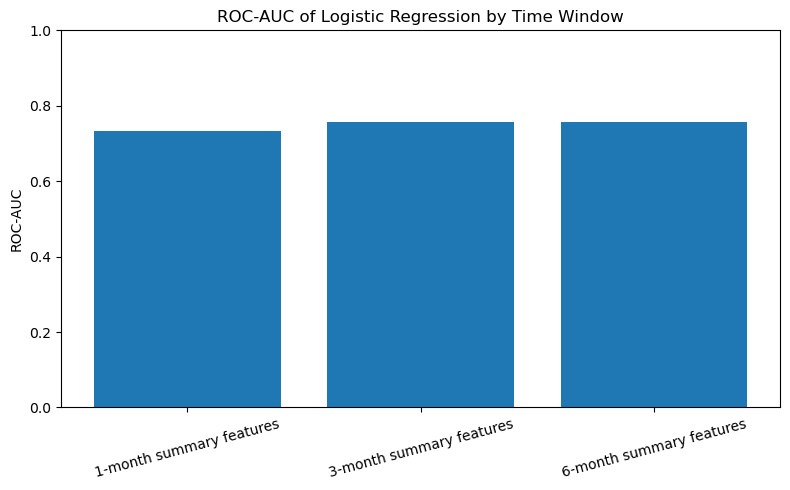

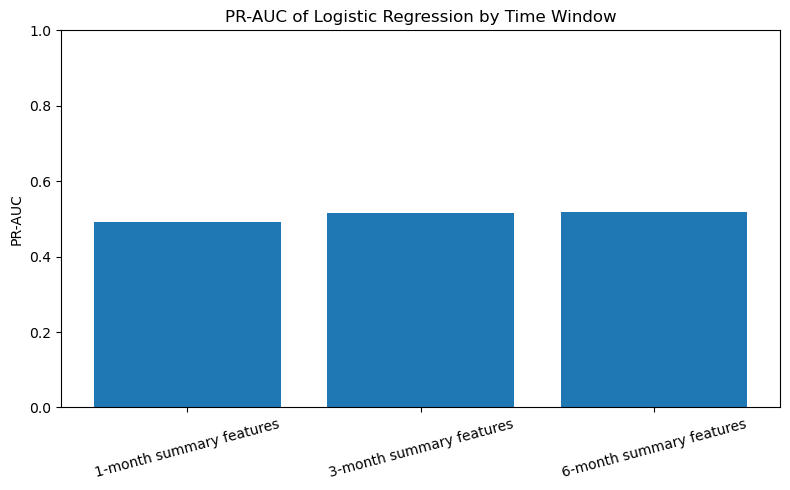

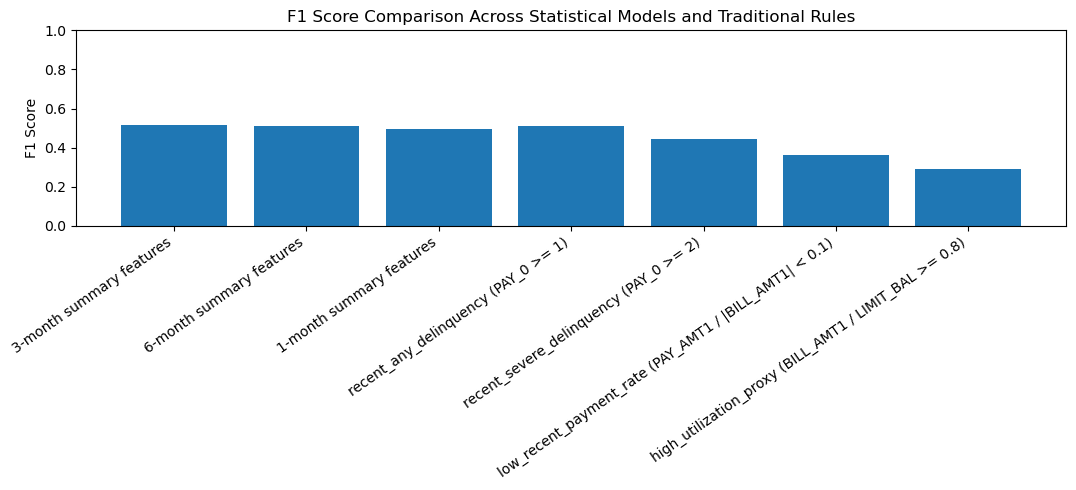

In [20]:
# Build logistic-model results table
logit_summary_rows = [
    {
        "model_type": "Logistic Regression",
        "model_name": "1-month summary features",
        "ROC_AUC": results_1m["ROC_AUC"],
        "PR_AUC": results_1m["PR_AUC"],
        "Accuracy": results_1m["Accuracy"],
        "Precision": results_1m["Precision"],
        "Recall": results_1m["Recall"],
        "F1": results_1m["F1"]
    },
    {
        "model_type": "Logistic Regression",
        "model_name": "3-month summary features",
        "ROC_AUC": results_3m["ROC_AUC"],
        "PR_AUC": results_3m["PR_AUC"],
        "Accuracy": results_3m["Accuracy"],
        "Precision": results_3m["Precision"],
        "Recall": results_3m["Recall"],
        "F1": results_3m["F1"]
    },
    {
        "model_type": "Logistic Regression",
        "model_name": "6-month summary features",
        "ROC_AUC": results_6m["ROC_AUC"],
        "PR_AUC": results_6m["PR_AUC"],
        "Accuracy": results_6m["Accuracy"],
        "Precision": results_6m["Precision"],
        "Recall": results_6m["Recall"],
        "F1": results_6m["F1"]
    }
]

logit_summary_df = pd.DataFrame(logit_summary_rows)

# Add placeholder ROC_AUC / PR_AUC columns to rule baselines
# since those rule outputs are hard class predictions, not scores
rule_summary_df = rule_results_df.copy()
rule_summary_df["model_type"] = "Traditional Rule"
rule_summary_df = rule_summary_df.rename(columns={"rule": "model_name"})
rule_summary_df["ROC_AUC"] = np.nan
rule_summary_df["PR_AUC"] = np.nan

rule_summary_df = rule_summary_df[
    ["model_type", "model_name", "ROC_AUC", "PR_AUC", "Accuracy", "Precision", "Recall", "F1"]
]

# Combine into one final table
final_results_df = pd.concat(
    [logit_summary_df, rule_summary_df],
    axis=0,
    ignore_index=True
)

final_results_df = final_results_df.sort_values(
    by=["model_type", "F1"],
    ascending=[True, False]
).reset_index(drop=True)

print("Final model comparison table:\n")
display(final_results_df.round(4))

# Plot 1: Logistic regression ROC-AUC across time windows
logit_plot_df = logit_summary_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(logit_plot_df["model_name"], logit_plot_df["ROC_AUC"])
plt.title("ROC-AUC of Logistic Regression by Time Window")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# Plot 2: Logistic regression PR-AUC across time windows
plt.figure(figsize=(8, 5))
plt.bar(logit_plot_df["model_name"], logit_plot_df["PR_AUC"])
plt.title("PR-AUC of Logistic Regression by Time Window")
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Plot 3: F1 score comparison across all models/rules
plt.figure(figsize=(11, 5))
plt.bar(final_results_df["model_name"], final_results_df["F1"])
plt.title("F1 Score Comparison Across Statistical Models and Traditional Rules")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.neighbors import KNeighborsClassifier

def tune_knn(X, y):
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )
    
    # Identify categorical and numeric columns
    categorical_cols = [col for col in ["SEX", "EDUCATION", "MARRIAGE"] if col in X.columns]
    numeric_cols = [col for col in X.columns if col not in categorical_cols]
    
    # Preprocessing
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )
    
    # Pipeline
    knn_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier())
    ])
    
    # Hyperparameter grid
    param_grid = {
        "model__n_neighbors": [5, 11, 21, 31],
        "model__weights": ["uniform", "distance"]
    }

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    grid = GridSearchCV(
        estimator=knn_pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    
    # Fit
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_

    # Evaluate on held-out test set
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= 0.50).astype(int)
    
    results = {
        "best_params": grid.best_params_,
        "ROC_AUC": roc_auc_score(y_test, y_test_proba),
        "PR_AUC": average_precision_score(y_test, y_test_proba),
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "F1": f1_score(y_test, y_test_pred, zero_division=0),
        "Confusion_Matrix": confusion_matrix(y_test, y_test_pred)
    }
    
    return best_model, results

# Train and evaluate k-NN on the 6-month summary features
best_knn_6m, knn_results_6m = tune_knn(X_6m_sum, y)

print("Best 6-Month k-NN Results:\n")
print("Best Parameters:", knn_results_6m["best_params"])
print(f"ROC_AUC:   {knn_results_6m['ROC_AUC']:.4f}")
print(f"PR_AUC:    {knn_results_6m['PR_AUC']:.4f}")
print(f"Accuracy:  {knn_results_6m['Accuracy']:.4f}")
print(f"Precision: {knn_results_6m['Precision']:.4f}")
print(f"Recall:    {knn_results_6m['Recall']:.4f}")
print(f"F1:        {knn_results_6m['F1']:.4f}")
print("Confusion Matrix:\n", knn_results_6m["Confusion_Matrix"])

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best 6-Month k-NN Results:

Best Parameters: {'model__n_neighbors': 31, 'model__weights': 'uniform'}
ROC_AUC:   0.7544
PR_AUC:    0.5122
Accuracy:  0.8147
Precision: 0.6435
Recall:    0.3632
F1:        0.4644
Confusion Matrix:
 [[4406  267]
 [ 845  482]]


Final comparison table including k-NN:



,model_type,model_name,ROC_AUC,PR_AUC,Accuracy,Precision,Recall,F1
0,Logistic Regression,3-month summary features,0.7571,0.5156,0.7672,0.4777,0.5659,0.5181
1,Logistic Regression,6-month summary features,0.7558,0.5174,0.7432,0.4413,0.6066,0.5109
2,k-NN,6-month summary features,0.7544,0.5122,0.8147,0.6435,0.3632,0.4644
3,Logistic Regression,1-month summary features,0.7337,0.4917,0.7730,0.4872,0.5034,0.4952
4,Traditional Rule,recent_any_delinquency (PAY_0 >= 1),NaN,NaN,0.7801,0.5029,0.5167,0.5097
5,Traditional Rule,recent_severe_delinquency (PAY_0 >= 2),NaN,NaN,0.8196,0.6955,0.3281,0.4458
6,Traditional Rule,low_recent_payment_rate (PAY_AMT1 / |BILL_AMT1...,NaN,NaN,0.4668,0.2477,0.6924,0.3649
7,Traditional Rule,high_utilization_proxy (BILL_AMT1 / LIMIT_BAL ...,NaN,NaN,0.6550,0.2673,0.3214,0.2919


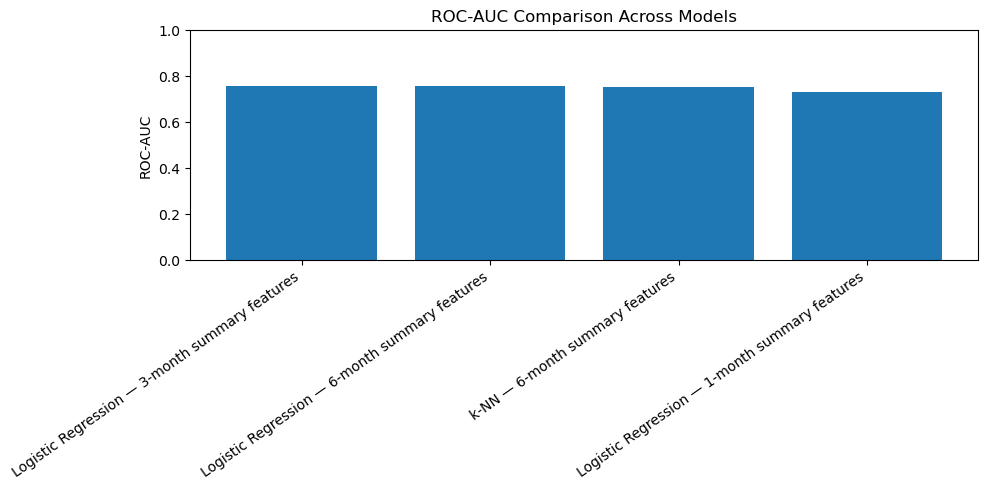

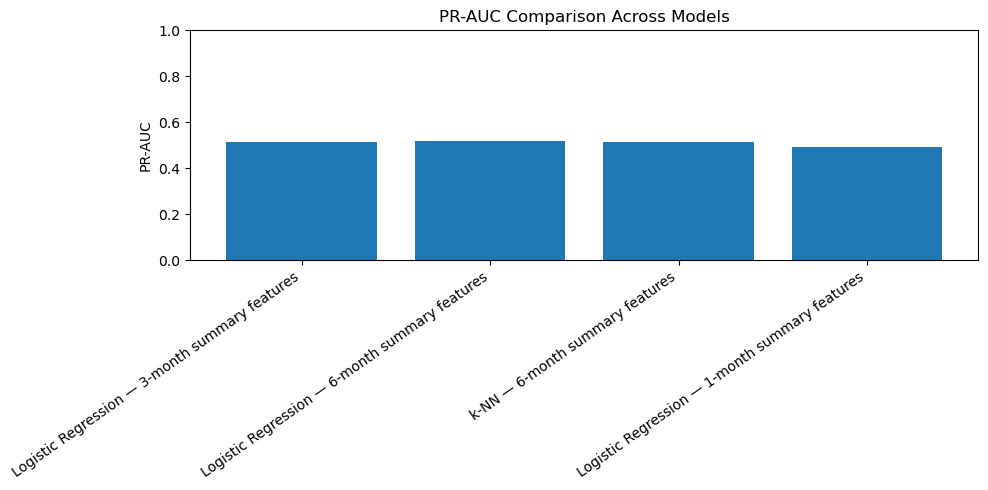

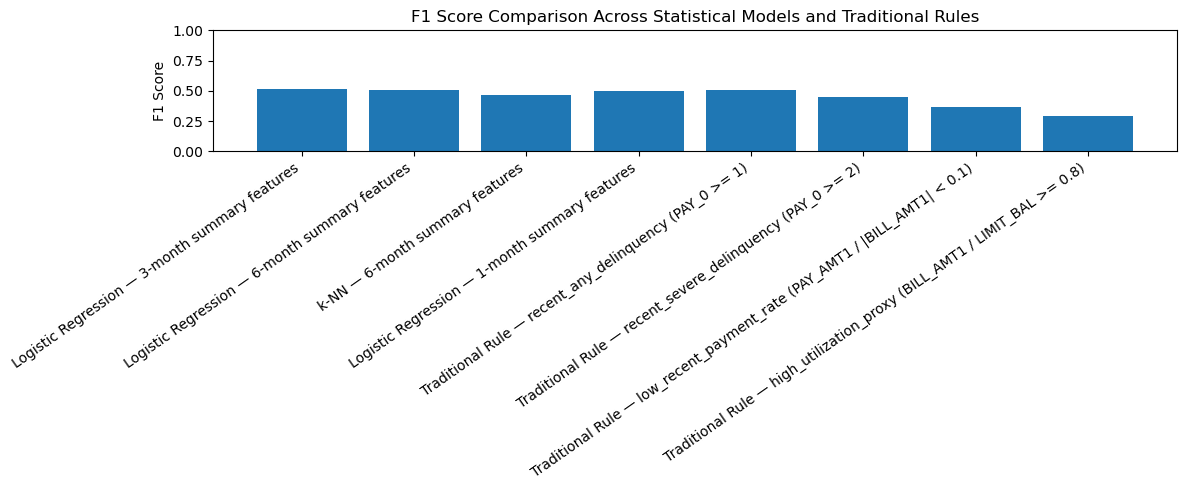

In [42]:
# Create a one-row DataFrame for k-NN results

knn_summary_row = pd.DataFrame([
    {
        "model_type": "k-NN",
        "model_name": "6-month summary features",
        "ROC_AUC": knn_results_6m["ROC_AUC"],
        "PR_AUC": knn_results_6m["PR_AUC"],
        "Accuracy": knn_results_6m["Accuracy"],
        "Precision": knn_results_6m["Precision"],
        "Recall": knn_results_6m["Recall"],
        "F1": knn_results_6m["F1"]
    }
])

# Append k-NN to the existing final results table
final_results_with_knn_df = pd.concat(
    [final_results_df, knn_summary_row],
    axis=0,
    ignore_index=True
)

final_results_with_knn_df = final_results_with_knn_df.sort_values(
    by=["ROC_AUC", "F1"],
    ascending=[False, False],
    na_position="last"
).reset_index(drop=True)

print("Final comparison table including k-NN:\n")
display(final_results_with_knn_df.round(4))

# Plot 1: ROC-AUC comparison across models with score outputs
roc_plot_df = final_results_with_knn_df.dropna(subset=["ROC_AUC"]).copy()

plt.figure(figsize=(10, 5))
plt.bar(roc_plot_df["model_type"] + " — " + roc_plot_df["model_name"], roc_plot_df["ROC_AUC"])
plt.title("ROC-AUC Comparison Across Models")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Plot 2: PR-AUC comparison across models with score outputs
pr_plot_df = final_results_with_knn_df.dropna(subset=["PR_AUC"]).copy()

plt.figure(figsize=(10, 5))
plt.bar(pr_plot_df["model_type"] + " — " + pr_plot_df["model_name"], pr_plot_df["PR_AUC"])
plt.title("PR-AUC Comparison Across Models")
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Plot 3: F1 comparison across all models and rules
plt.figure(figsize=(12, 5))
plt.bar(
    final_results_with_knn_df["model_type"] + " — " + final_results_with_knn_df["model_name"],
    final_results_with_knn_df["F1"]
)
plt.title("F1 Score Comparison Across Statistical Models and Traditional Rules")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

KEY FINDINGS TABLE


,model_type,model_name,ROC_AUC,PR_AUC,Recall,F1
0,Logistic Regression,3-month summary features,0.7571,0.5156,0.5659,0.5181
1,Logistic Regression,6-month summary features,0.7558,0.5174,0.6066,0.5109
2,k-NN,6-month summary features,0.7544,0.5122,0.3632,0.4644
3,Logistic Regression,1-month summary features,0.7337,0.4917,0.5034,0.4952
4,Traditional Rule,recent_any_delinquency (PAY_0 >= 1),NaN,NaN,0.5167,0.5097
5,Traditional Rule,recent_severe_delinquency (PAY_0 >= 2),NaN,NaN,0.3281,0.4458
6,Traditional Rule,low_recent_payment_rate (PAY_AMT1 / |BILL_AMT1...,NaN,NaN,0.6924,0.3649
7,Traditional Rule,high_utilization_proxy (BILL_AMT1 / LIMIT_BAL ...,NaN,NaN,0.3214,0.2919


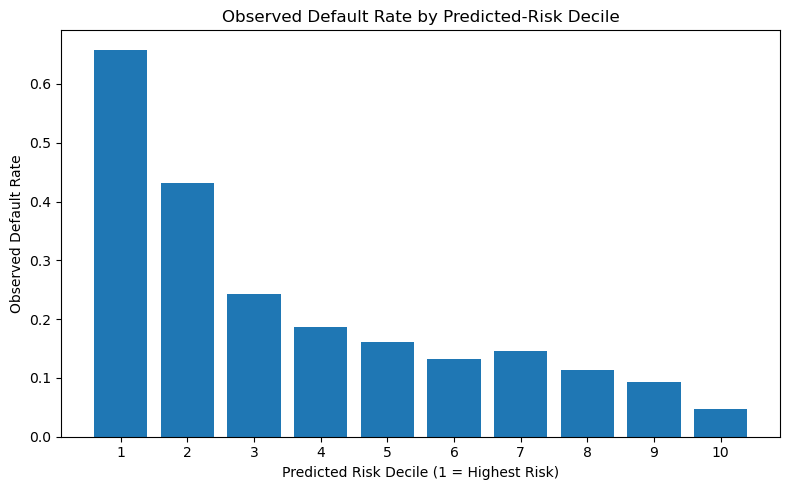

In [43]:
# ============================================================
# KEY FINDINGS — 1 TABLE + 1 GRAPH
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# TABLE: key model comparison table

# Prefer final table with k-NN if available, otherwise use final_results_df
if "final_results_with_knn_df" in globals():
    key_table_df = final_results_with_knn_df.copy()
elif "final_results_df" in globals():
    key_table_df = final_results_df.copy()
else:
    key_table_df = pd.DataFrame([
        {
            "model_type": "Logistic Regression",
            "model_name": "1-month summary features",
            "ROC_AUC": results_1m["ROC_AUC"],
            "PR_AUC": results_1m["PR_AUC"],
            "Accuracy": results_1m["Accuracy"],
            "Precision": results_1m["Precision"],
            "Recall": results_1m["Recall"],
            "F1": results_1m["F1"]
        },
        {
            "model_type": "Logistic Regression",
            "model_name": "3-month summary features",
            "ROC_AUC": results_3m["ROC_AUC"],
            "PR_AUC": results_3m["PR_AUC"],
            "Accuracy": results_3m["Accuracy"],
            "Precision": results_3m["Precision"],
            "Recall": results_3m["Recall"],
            "F1": results_3m["F1"]
        },
        {
            "model_type": "Logistic Regression",
            "model_name": "6-month summary features",
            "ROC_AUC": results_6m["ROC_AUC"],
            "PR_AUC": results_6m["PR_AUC"],
            "Accuracy": results_6m["Accuracy"],
            "Precision": results_6m["Precision"],
            "Recall": results_6m["Recall"],
            "F1": results_6m["F1"]
        }
    ])

key_table_df = key_table_df.copy()
key_table_df = key_table_df[[
    "model_type", "model_name", "ROC_AUC", "PR_AUC", "Recall", "F1"
]]

if "ROC_AUC" in key_table_df.columns:
    key_table_df = key_table_df.sort_values(by="ROC_AUC", ascending=False, na_position="last").reset_index(drop=True)

print("KEY FINDINGS TABLE")
display(key_table_df.round(4))

# GRAPH: observed default rate by predicted-risk decile
if "decile_summary" not in globals():
    # recreate from tuned 6-month logistic model
    from sklearn.model_selection import train_test_split

    X_train_6m, X_test_6m, y_train_6m, y_test_6m = train_test_split(
        X_6m_sum,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    y_score_6m = best_logit_6m.predict_proba(X_test_6m)[:, 1]

    lift_df = pd.DataFrame({
        "y_true": y_test_6m.values,
        "score": y_score_6m
    }).sort_values("score", ascending=False).reset_index(drop=True)

    lift_df["decile"] = pd.qcut(
        lift_df["score"].rank(method="first", ascending=False),
        10,
        labels=[1,2,3,4,5,6,7,8,9,10]
    )

    decile_summary = lift_df.groupby("decile").agg(
        accounts=("y_true", "size"),
        defaults=("y_true", "sum"),
        default_rate=("y_true", "mean"),
        avg_score=("score", "mean")
    ).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(decile_summary["decile"].astype(str), decile_summary["default_rate"])
plt.xlabel("Predicted Risk Decile (1 = Highest Risk)")
plt.ylabel("Observed Default Rate")
plt.title("Observed Default Rate by Predicted-Risk Decile")
plt.tight_layout()
plt.show()